# Perbandingan Model Klasifikasi Penyakit Daun Duren
Notebook ini membandingkan 4 pendekatan:
1. CNN Biasa
2. Transfer Learning (MobileNetV2)
3. Siamese Network (embedding + nearest prototype)
4. Prototypical Network

## CRISP-DM Roadmap Notebook
- Business Understanding / Setup
- Data Understanding
- Data Preparation
- Modeling
- Evaluation
- Deployment (Transfer Learning sebagai model final riset)


In [ ]:
# [CRISP-DM: Business Understanding / Setup] [SAFE-RERUN]
# Jika di Colab, aktifkan jika paket belum tersedia
# !pip install -q tensorflow scikit-learn pandas matplotlib seaborn
# Pilih True untuk mode cepat pelatihan dan False untuk mode pelatihan mendalam

In [ ]:
# [CRISP-DM: Business Understanding / Setup] [RUN-ONCE-IF-NEEDED]
!pip install -q tensorflow scikit-learn pandas matplotlib seaborn

In [1]:
# [CRISP-DM: Data Understanding / Config] [SAFE-RERUN]
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import classification_report, accuracy_score

print('TensorFlow:', tf.__version__)

# Mount Google Drive hanya jika berjalan di Colab
if 'google.colab' in str(getattr(__import__('sys'), 'modules', {})):
    from google.colab import drive
    drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = '/content/drive/MyDrive/Colab Notebooks/Duren/dataset_duren'

# Pilih True untuk mode cepat pelatihan dan False untuk mode pelatihan mendalam
FAST_MODE = False

if FAST_MODE:
    IMG_SIZE = (160, 160)
    BATCH_SIZE = 32
    EPOCHS_CNN = 10
    EPOCHS_TL_HEAD = 6
    EPOCHS_TL_FT = 4
    EPOCHS_SIAMESE = 3
    SIAMESE_TRAIN_PAIRS = 1200
    SIAMESE_VAL_PAIRS = 300
    PROTO_SUPPORT = 5
    PROTO_QUERY = 5
    PROTO_EPISODES = 120
else:
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS_CNN = 25
    EPOCHS_TL_HEAD = 15
    EPOCHS_TL_FT = 10
    EPOCHS_SIAMESE = 6
    SIAMESE_TRAIN_PAIRS = 2400
    SIAMESE_VAL_PAIRS = 600
    PROTO_SUPPORT = 5
    PROTO_QUERY = 5
    PROTO_EPISODES = 300

AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR = os.path.join(DATA_ROOT, 'val')
TEST_DIR = os.path.join(DATA_ROOT, 'test')

for pth in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.exists(pth):
        raise FileNotFoundError(f'Folder tidak ditemukan: {pth}')

class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
num_classes = len(class_names)
print('Classes:', class_names)
print('Jumlah kelas:', num_classes)
print('FAST_MODE:', FAST_MODE)


TensorFlow: 2.19.0
Mounted at /content/drive
Classes: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
Jumlah kelas: 5
FAST_MODE: False


In [2]:
# [CRISP-DM: Data Understanding] [SAFE-RERUN]
# Ringkasan jumlah data per split dan kelas
summary = []
for split_name, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    total = 0
    for c in class_names:
        cdir = os.path.join(split_dir, c)
        n = len([f for f in os.listdir(cdir) if os.path.isfile(os.path.join(cdir, f))])
        total += n
        summary.append({'split': split_name, 'class': c, 'count': n})
    summary.append({'split': split_name, 'class': 'TOTAL', 'count': total})

summary_df = pd.DataFrame(summary)
summary_df


,split,class,count
0,train,ALGAL_LEAF_SPOT,513
1,train,ALLOCARIDARA_ATTACK,639
2,train,HEALTHY_LEAF,683
3,train,LEAF_BLIGHT,655
4,train,PHOMOPSIS_LEAF_SPOT,614
5,train,TOTAL,3104
6,val,ALGAL_LEAF_SPOT,73
7,val,ALLOCARIDARA_ATTACK,91
8,val,HEALTHY_LEAF,97
9,val,LEAF_BLIGHT,94


In [3]:
# [CRISP-DM: Data Preparation] [SAFE-RERUN]
# Data loader untuk CNN baseline dan Transfer Learning
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

rescale_01 = tf.keras.layers.Rescaling(1./255)

# Heavy geometric augmentation khusus CNN baseline
geom_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomTranslation(0.2, 0.2, seed=SEED),
    tf.keras.layers.RandomZoom(0.2, seed=SEED)
], name='cnn_heavy_geom_aug')

train_ds_cnn = train_ds_raw.map(
    lambda x, y: (rescale_01(geom_aug(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
val_ds_cnn = val_ds_raw.map(lambda x, y: (rescale_01(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_cnn = test_ds_raw.map(lambda x, y: (rescale_01(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# TL: input tetap [0,1], normalisasi mean/std ImageNet dilakukan di dalam model
train_ds_tl = train_ds_raw.map(lambda x, y: (rescale_01(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_tl = val_ds_raw.map(lambda x, y: (rescale_01(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_tl = test_ds_raw.map(lambda x, y: (rescale_01(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


Found 3104 files belonging to 5 classes.
Found 443 files belonging to 5 classes.
Found 890 files belonging to 5 classes.


In [4]:
# [CRISP-DM: Modeling - CNN Baseline] [SAFE-RERUN]
def make_basic_cnn(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='basic_cnn_bn_dropout')

cnn_model = make_basic_cnn(input_shape=(*IMG_SIZE, 3), num_classes=num_classes)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()


Model: "basic_cnn_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,229 (500.89 KB)

 Trainable params: 127,781 (499.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# [CRISP-DM: Modeling - Training Utilities] [SAFE-RERUN]
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
]

history_cnn = cnn_model.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=EPOCHS_CNN,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 590s 6s/step - accuracy: 0.3400 - loss: 1.5221 - val_accuracy: 0.2190 - val_loss: 1.7083
Epoch 2/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 49s 496ms/step - accuracy: 0.4129 - loss: 1.3772 - val_accuracy: 0.2190 - val_loss: 1.8620
Epoch 3/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 50s 507ms/step - accuracy: 0.4410 - loss: 1.3354 - val_accuracy: 0.2190 - val_loss: 2.0919
Epoch 4/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 49s 497ms/step - accuracy: 0.4322 - loss: 1.3319 - val_accuracy: 0.2190 - val_loss: 1.9840
Epoch 5/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 49s 504ms/step - accuracy: 0.4481 - loss: 1.3272 - val_accuracy: 0.2889 - val_loss: 1.5100
Epoch 6/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 82s 509ms/step - accuracy: 0.4658 - loss: 1.2886 - val_accuracy: 0.5102 - val_loss: 1.2383
Epoch 7/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 48s 493ms/step - accuracy: 0.4886 - loss: 1.2771 - val_accuracy: 0.4199 - val_loss: 1.3333
Epoch 8/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 49s 495ms/step - accuracy: 0.4771 - loss: 1.2836 - val_accura

In [6]:
# [CRISP-DM: Evaluation - Utilities] [SAFE-RERUN]
def evaluate_classifier(model, dataset, class_names, name='model'):
    y_true = []
    y_pred = []
    for x_batch, y_batch in dataset:
        pred = model.predict(x_batch, verbose=0)
        y_true.extend(y_batch.numpy().tolist())
        y_pred.extend(np.argmax(pred, axis=1).tolist())
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f'=== {name} ===')
    print('Accuracy:', round(acc, 4))
    print(report)
    return acc, y_true, y_pred

acc_cnn, y_true_cnn, y_pred_cnn = evaluate_classifier(cnn_model, test_ds_cnn, class_names, 'CNN Biasa')


=== CNN Biasa ===
Accuracy: 0.4899
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT     0.5789    0.2245    0.3235       147
ALLOCARIDARA_ATTACK     0.4011    0.3989    0.4000       183
       HEALTHY_LEAF     0.6185    0.5459    0.5799       196
        LEAF_BLIGHT     0.4884    0.5585    0.5211       188
PHOMOPSIS_LEAF_SPOT     0.4487    0.6705    0.5376       176

           accuracy                         0.4899       890
          macro avg     0.5071    0.4797    0.4724       890
       weighted avg     0.5062    0.4899    0.4798       890



In [7]:
# [CRISP-DM: Modeling - Transfer Learning] [SAFE-RERUN]
def make_transfer_model(input_shape=(224, 224, 3), num_classes=5):
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)

    # ImageNet stats normalization: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
    std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    x = tf.keras.layers.Lambda(lambda z: (z - mean) / std, name='imagenet_stats_norm')(inputs)

    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='transfer_mobilenetv2')
    return model, base

transfer_model, transfer_base = make_transfer_model(input_shape=(*IMG_SIZE, 3), num_classes=num_classes)
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ imagenet_stats_norm (Lambda)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# [CRISP-DM: Modeling - Transfer Learning Train] [RUN-ONCE-MAHAL]
# Fallback callbacks jika cell CNN belum dijalankan
if 'callbacks' not in globals():
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        )
    ]

history_tl = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCHS_TL_HEAD,
    callbacks=callbacks,
    verbose=1
)

# Fine-tuning ringan
transfer_base.trainable = True
for layer in transfer_base.layers[:-20]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_ft = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCHS_TL_FT,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 52s 290ms/step - accuracy: 0.2976 - loss: 1.8198 - val_accuracy: 0.5350 - val_loss: 1.1266
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.5341 - loss: 1.1714 - val_accuracy: 0.6117 - val_loss: 1.0022
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.6050 - loss: 1.0169 - val_accuracy: 0.6479 - val_loss: 0.9494
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.6208 - loss: 0.9563 - val_accuracy: 0.6433 - val_loss: 0.9526
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.6596 - loss: 0.8873 - val_accuracy: 0.6569 - val_loss: 0.9004
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.6715 - loss: 0.8304 - val_accuracy: 0.6614 - val_loss: 0.8772
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.6830 - loss: 0.8312 - val_accuracy: 0.6524 - val_loss: 0.9000
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.6876 - loss: 0.8241 - val_accu

In [9]:
# [CRISP-DM: Evaluation - Transfer Learning] [SAFE-RERUN]
acc_tl, y_true_tl, y_pred_tl = evaluate_classifier(transfer_model, test_ds_tl, class_names, 'Transfer Learning')


=== Transfer Learning ===
Accuracy: 0.7281
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT     0.7122    0.6735    0.6923       147
ALLOCARIDARA_ATTACK     0.8377    0.7049    0.7656       183
       HEALTHY_LEAF     0.7568    0.8571    0.8038       196
        LEAF_BLIGHT     0.7094    0.7660    0.7366       188
PHOMOPSIS_LEAF_SPOT     0.6279    0.6136    0.6207       176

           accuracy                         0.7281       890
          macro avg     0.7288    0.7230    0.7238       890
       weighted avg     0.7305    0.7281    0.7271       890



In [10]:
# [CRISP-DM: Data Preparation - Metric Learning Arrays] [RUN-ONCE-MAHAL]
# Utilitas untuk Siamese & Prototypical: load image ke array (LOW RAM)
import pathlib

ARRAY_DTYPE = np.float16  # simpan array embedding-task sebagai float16 agar RAM lebih hemat


def load_split_as_arrays(split_dir, class_names, img_size=(224, 224), array_dtype=ARRAY_DTYPE):
    xs, ys = [], []
    for label, cls in enumerate(class_names):
        cdir = os.path.join(split_dir, cls)
        if not os.path.isdir(cdir):
            continue
        for fname in sorted(os.listdir(cdir)):
            fpath = os.path.join(cdir, fname)
            if not os.path.isfile(fpath):
                continue
            try:
                img = tf.keras.utils.load_img(fpath, target_size=img_size)
                arr = tf.keras.utils.img_to_array(img) / 255.0
                xs.append(arr.astype(array_dtype, copy=False))
                ys.append(label)
            except Exception:
                pass
    return np.asarray(xs, dtype=array_dtype), np.asarray(ys, dtype=np.int32)


def _arr_mb(arr):
    return arr.nbytes / (1024 ** 2)


x_train, y_train = load_split_as_arrays(TRAIN_DIR, class_names, IMG_SIZE)
x_val, y_val = load_split_as_arrays(VAL_DIR, class_names, IMG_SIZE)
x_test, y_test = load_split_as_arrays(TEST_DIR, class_names, IMG_SIZE)

print('Train:', x_train.shape, y_train.shape, '| dtype:', x_train.dtype, '| RAM:', round(_arr_mb(x_train), 1), 'MB')
print('Val  :', x_val.shape, y_val.shape, '| dtype:', x_val.dtype, '| RAM:', round(_arr_mb(x_val), 1), 'MB')
print('Test :', x_test.shape, y_test.shape, '| dtype:', x_test.dtype, '| RAM:', round(_arr_mb(x_test), 1), 'MB')


Train: (3104, 224, 224, 3) (3104,) | dtype: float16 | RAM: 891.2 MB
Val  : (443, 224, 224, 3) (443,) | dtype: float16 | RAM: 127.2 MB
Test : (890, 224, 224, 3) (890,) | dtype: float16 | RAM: 255.5 MB


In [11]:
# [CRISP-DM: Modeling - Metric Learning Encoder] [SAFE-RERUN]
def make_encoder(input_shape=(224,224,3), emb_dim=128):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(emb_dim)(x)
    outputs = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name='l2_norm')(x)
    return tf.keras.Model(inputs, outputs, name='encoder')


In [12]:
# [CRISP-DM: Modeling - Siamese] [RUN-ONCE-MAHAL]
# Siamese Network (Triplet Loss + Hard Negative Mining) - LOW RAM ROBUST (SELF-CONTAINED)
import gc
import os
import pathlib
import random
import numpy as np
import tensorflow as tf
from collections import defaultdict


def _find_dataset_root():
    candidates = []
    if 'DATA_ROOT' in globals() and isinstance(DATA_ROOT, str):
        candidates.append(DATA_ROOT)
    candidates.extend([
        './dataset_duren',
        'dataset_duren',
        '/content/dataset_duren',
        '/content/drive/MyDrive/Colab Notebooks/Duren/dataset_duren',
        '/content/drive/MyDrive/Duren/dataset_duren',
    ])
    # cari rekursif ringan (maks 2 level) dari cwd
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'dataset_duren':
                candidates.append(str(p))
    except Exception:
        pass

    seen = set()
    for root in candidates:
        if not root:
            continue
        root = str(root)
        if root in seen:
            continue
        seen.add(root)
        train_dir = os.path.join(root, 'train')
        val_dir = os.path.join(root, 'val')
        test_dir = os.path.join(root, 'test')
        if os.path.isdir(train_dir) and os.path.isdir(val_dir) and os.path.isdir(test_dir):
            return root
    raise FileNotFoundError(
        'Dataset tidak ditemukan. Pastikan folder dataset_duren dengan subfolder train/val/test tersedia '
        'atau set DATA_ROOT terlebih dahulu.'
    )


def _ensure_dataset_vars():
    global DATA_ROOT, TRAIN_DIR, VAL_DIR, TEST_DIR, class_names, num_classes

    need_paths = not all(k in globals() for k in ['TRAIN_DIR', 'VAL_DIR', 'TEST_DIR'])
    if need_paths:
        DATA_ROOT = _find_dataset_root()
        TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
        VAL_DIR = os.path.join(DATA_ROOT, 'val')
        TEST_DIR = os.path.join(DATA_ROOT, 'test')

    if 'class_names' not in globals() or not globals().get('class_names'):
        class_names = sorted([
            d for d in os.listdir(TRAIN_DIR)
            if os.path.isdir(os.path.join(TRAIN_DIR, d))
        ])
    if 'num_classes' not in globals() or not isinstance(globals().get('num_classes'), int):
        num_classes = len(class_names)

    if len(class_names) < 2:
        raise ValueError('Minimal butuh 2 kelas pada folder train untuk Siamese triplet training.')


def _load_split_as_arrays_fallback(split_dir, class_names, img_size=(224, 224), array_dtype=np.float16):
    xs, ys = [], []
    for label, cls in enumerate(class_names):
        cdir = os.path.join(split_dir, cls)
        if not os.path.isdir(cdir):
            continue
        for fname in sorted(os.listdir(cdir)):
            fpath = os.path.join(cdir, fname)
            if not os.path.isfile(fpath):
                continue
            try:
                img = tf.keras.utils.load_img(fpath, target_size=img_size)
                arr = tf.keras.utils.img_to_array(img) / 255.0
                xs.append(arr.astype(array_dtype, copy=False))
                ys.append(label)
            except Exception:
                pass
    return np.asarray(xs, dtype=array_dtype), np.asarray(ys, dtype=np.int32)


# Bebaskan memori dari model/dataset sebelumnya agar cell ini bisa dijalankan ulang sendiri
for _name in [
    'cnn_model', 'transfer_model', 'transfer_base', 'history_cnn', 'history_tl', 'history_tl_ft',
    'train_ds_cnn', 'val_ds_cnn', 'test_ds_cnn', 'train_ds_tl', 'val_ds_tl', 'test_ds_tl',
    'siamese_model', 'encoder_siam', 'siamese_protos'
]:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass

try:
    tf.keras.backend.clear_session()
except Exception:
    pass
gc.collect()

try:
    for _gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(_gpu, True)
except Exception:
    pass

# Fallback encoder jika cell make_encoder belum dijalankan
if 'make_encoder' not in globals():
    def make_encoder(input_shape=(224, 224, 3), emb_dim=128):
        inputs = tf.keras.Input(shape=input_shape)
        x = tf.keras.layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling2D()(x)
        x = tf.keras.layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling2D()(x)
        x = tf.keras.layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dense(emb_dim)(x)
        outputs = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name='l2_norm')(x)
        return tf.keras.Model(inputs, outputs, name='encoder')

# Fallback konfigurasi jika sel awal belum dijalankan
if 'FAST_MODE' not in globals():
    FAST_MODE = False
if 'IMG_SIZE' not in globals():
    IMG_SIZE = (160, 160) if FAST_MODE else (224, 224)
if 'EPOCHS_SIAMESE' not in globals():
    EPOCHS_SIAMESE = 3 if FAST_MODE else 6
if 'SEED' not in globals():
    SEED = 42

random.seed(int(SEED))
np.random.seed(int(SEED))
tf.random.set_seed(int(SEED))

_ensure_dataset_vars()
print('DATA_ROOT:', DATA_ROOT)
print('Classes:', class_names)

# Sediakan loader array jika sel sebelumnya belum dijalankan
if 'load_split_as_arrays' not in globals():
    load_split_as_arrays = _load_split_as_arrays_fallback

required_vars = ['x_train', 'y_train', 'x_val', 'y_val']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print('Auto-loading array train/val untuk Siamese (self-contained mode)...')
    x_train, y_train = load_split_as_arrays(TRAIN_DIR, class_names, IMG_SIZE)
    x_val, y_val = load_split_as_arrays(VAL_DIR, class_names, IMG_SIZE)
    # Test tidak wajib untuk training, sengaja tidak di-load di sini agar RAM lebih aman
    missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f'Variabel belum tersedia: {missing}.')

# Pastikan dtype ringan dan konsisten
if isinstance(x_train, np.ndarray) and x_train.dtype != np.float16:
    x_train = x_train.astype(np.float16, copy=False)
if isinstance(x_val, np.ndarray) and x_val.dtype != np.float16:
    x_val = x_val.astype(np.float16, copy=False)
if isinstance(y_train, np.ndarray) and y_train.dtype != np.int32:
    y_train = y_train.astype(np.int32, copy=False)
if isinstance(y_val, np.ndarray) and y_val.dtype != np.int32:
    y_val = y_val.astype(np.int32, copy=False)


def _mb(arr):
    return (arr.nbytes / (1024**2)) if isinstance(arr, np.ndarray) else 0.0

print(f'RAM arrays -> train: {_mb(x_train):.1f} MB | val: {_mb(x_val):.1f} MB')

# Parameter konservatif + auto-fallback OOM
SIAMESE_EMB_DIM = int(globals().get('SIAMESE_EMB_DIM', 96 if max(IMG_SIZE) >= 224 else 128))
SIAMESE_PRED_BATCH = int(globals().get('SIAMESE_PRED_BATCH', 32 if max(IMG_SIZE) >= 224 else 64))
SIAMESE_BATCH_TRIPLETS = int(globals().get('SIAMESE_BATCH_TRIPLETS', 16 if max(IMG_SIZE) >= 224 else 24))
SIAMESE_TRAIN_STEPS = int(globals().get('SIAMESE_TRAIN_STEPS', 6 if FAST_MODE else 12))
SIAMESE_VAL_STEPS = int(globals().get('SIAMESE_VAL_STEPS', 2 if FAST_MODE else 3))
SIAMESE_NEG_CAND_TRAIN = int(globals().get('SIAMESE_NEG_CAND_TRAIN', 6))
SIAMESE_NEG_CAND_VAL = int(globals().get('SIAMESE_NEG_CAND_VAL', 4))
SIAMESE_MARGIN = float(globals().get('SIAMESE_MARGIN', 0.25))


def build_siamese_triplet_model(input_shape, emb_dim=128):
    encoder = make_encoder(input_shape=input_shape, emb_dim=emb_dim)
    a_in = tf.keras.Input(shape=input_shape, name='anchor')
    p_in = tf.keras.Input(shape=input_shape, name='positive')
    n_in = tf.keras.Input(shape=input_shape, name='negative')
    a_emb = encoder(a_in)
    p_emb = encoder(p_in)
    n_emb = encoder(n_in)
    out = tf.keras.layers.Concatenate(axis=1)([a_emb, p_emb, n_emb])
    model = tf.keras.Model([a_in, p_in, n_in], out, name='siamese_triplet')
    return model, encoder


def triplet_loss(margin=0.25):
    def loss(_, y_pred):
        a, p, n = tf.split(y_pred, num_or_size_splits=3, axis=1)
        d_ap = tf.reduce_sum(tf.square(a - p), axis=1)
        d_an = tf.reduce_sum(tf.square(a - n), axis=1)
        return tf.reduce_mean(tf.maximum(d_ap - d_an + margin, 0.0))
    return loss


def triplet_acc(_, y_pred):
    a, p, n = tf.split(y_pred, num_or_size_splits=3, axis=1)
    d_ap = tf.reduce_sum(tf.square(a - p), axis=1)
    d_an = tf.reduce_sum(tf.square(a - n), axis=1)
    return tf.reduce_mean(tf.cast(d_ap < d_an, tf.float32))


def make_class_index(y):
    c2i = defaultdict(list)
    for i, cls in enumerate(y):
        c2i[int(cls)].append(i)
    return c2i


@tf.function(reduce_retracing=True)
def _augment_triplet_batch(batch):
    x = tf.image.random_flip_left_right(batch)
    x = tf.image.random_flip_up_down(x)
    x = tf.image.random_brightness(x, max_delta=0.06)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    return tf.clip_by_value(x, 0.0, 1.0)


def _safe_numpy_batch(x, idxs):
    return np.asarray(x[np.asarray(idxs, dtype=np.int32)], dtype=np.float32)


def predict_embeddings_chunked(encoder, x, batch_size=32, out_dtype=np.float16):
    n = int(len(x))
    emb_out = None
    for i in range(0, n, batch_size):
        xb = tf.convert_to_tensor(x[i:i + batch_size], dtype=tf.float32)
        eb = encoder(xb, training=False).numpy()
        if emb_out is None:
            emb_out = np.empty((n, eb.shape[1]), dtype=out_dtype)
        emb_out[i:i + eb.shape[0]] = eb.astype(out_dtype, copy=False)
        del xb, eb
    gc.collect()
    return emb_out


def make_triplet_batch_from_emb(emb, x, class_to_idx, batch_triplets=16, candidate_negatives=6):
    classes = [c for c, idxs in class_to_idx.items() if len(idxs) >= 2]
    if len(classes) < 2:
        raise ValueError('Perlu minimal 2 kelas dan tiap kelas >=2 sampel untuk triplet training.')

    other_classes = {c: [k for k in classes if k != c] for c in classes}
    a_idxs, p_idxs, n_idxs = [], [], []

    while len(a_idxs) < batch_triplets:
        c = random.choice(classes)
        a_idx, p_idx = random.sample(class_to_idx[c], 2)
        neg_pool_idx = []
        for _ in range(candidate_negatives):
            nc = random.choice(other_classes[c])
            neg_pool_idx.append(random.choice(class_to_idx[nc]))

        a_emb = emb[a_idx].astype(np.float32, copy=False)
        neg_emb = emb[np.asarray(neg_pool_idx, dtype=np.int32)].astype(np.float32, copy=False)
        hard_n = neg_pool_idx[int(np.argmax(neg_emb @ a_emb))]

        a_idxs.append(a_idx)
        p_idxs.append(p_idx)
        n_idxs.append(hard_n)

    a = _safe_numpy_batch(x, a_idxs)
    p = _safe_numpy_batch(x, p_idxs)
    n = _safe_numpy_batch(x, n_idxs)
    a = _augment_triplet_batch(tf.convert_to_tensor(a, dtype=tf.float32)).numpy()
    p = _augment_triplet_batch(tf.convert_to_tensor(p, dtype=tf.float32)).numpy()
    n = _augment_triplet_batch(tf.convert_to_tensor(n, dtype=tf.float32)).numpy()
    return a, p, n


siamese_model, encoder_siam = build_siamese_triplet_model(input_shape=(*IMG_SIZE, 3), emb_dim=SIAMESE_EMB_DIM)
siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=triplet_loss(margin=SIAMESE_MARGIN),
    metrics=[triplet_acc]
)

train_c2i = make_class_index(y_train)
val_c2i = make_class_index(y_val)

EPOCHS_SIAMESE = int(max(1, EPOCHS_SIAMESE))
steps_per_epoch = int(max(1, SIAMESE_TRAIN_STEPS))
val_steps = int(max(1, SIAMESE_VAL_STEPS))
batch_triplets = int(max(8, SIAMESE_BATCH_TRIPLETS))
pred_batch = int(max(8, SIAMESE_PRED_BATCH))
y_dummy = np.zeros((batch_triplets, 1), dtype=np.float32)

print(
    f'Siamese config -> emb_dim={SIAMESE_EMB_DIM}, pred_batch={pred_batch}, '
    f'triplets/batch={batch_triplets}, steps={steps_per_epoch}, val_steps={val_steps}'
)

for ep in range(1, EPOCHS_SIAMESE + 1):
    emb_train = predict_embeddings_chunked(encoder_siam, x_train, batch_size=pred_batch, out_dtype=np.float16)
    emb_val = predict_embeddings_chunked(encoder_siam, x_val, batch_size=pred_batch, out_dtype=np.float16)

    tr_losses, tr_accs = [], []
    for _ in range(steps_per_epoch):
        retried = False
        while True:
            try:
                a, p, n = make_triplet_batch_from_emb(
                    emb_train, x_train, train_c2i,
                    batch_triplets=batch_triplets,
                    candidate_negatives=SIAMESE_NEG_CAND_TRAIN
                )
                if y_dummy.shape[0] != batch_triplets:
                    y_dummy = np.zeros((batch_triplets, 1), dtype=np.float32)
                m = siamese_model.train_on_batch([a, p, n], y_dummy, return_dict=True)
                tr_losses.append(float(m['loss']))
                tr_accs.append(float(m['triplet_acc']))
                del a, p, n, m
                break
            except tf.errors.ResourceExhaustedError:
                if retried or batch_triplets <= 8:
                    raise
                batch_triplets = max(8, batch_triplets // 2)
                print(f'GPU/VRAM OOM terdeteksi -> batch_triplets diturunkan menjadi {batch_triplets}')
                retried = True
                gc.collect()

    va_losses, va_accs = [], []
    for _ in range(val_steps):
        a, p, n = make_triplet_batch_from_emb(
            emb_val, x_val, val_c2i,
            batch_triplets=batch_triplets,
            candidate_negatives=SIAMESE_NEG_CAND_VAL
        )
        if y_dummy.shape[0] != batch_triplets:
            y_dummy = np.zeros((batch_triplets, 1), dtype=np.float32)
        m = siamese_model.test_on_batch([a, p, n], y_dummy, return_dict=True)
        va_losses.append(float(m['loss']))
        va_accs.append(float(m['triplet_acc']))
        del a, p, n, m

    print(
        f'Epoch {ep}/{EPOCHS_SIAMESE} - '
        f'loss: {np.mean(tr_losses):.4f} - triplet_acc: {np.mean(tr_accs):.4f} - '
        f'val_loss: {np.mean(va_losses):.4f} - val_triplet_acc: {np.mean(va_accs):.4f}'
    )

    del emb_train, emb_val, tr_losses, tr_accs, va_losses, va_accs
    gc.collect()


DATA_ROOT: /content/drive/MyDrive/Colab Notebooks/Duren/dataset_duren
Classes: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
RAM arrays -> train: 891.2 MB | val: 127.2 MB
Siamese config -> emb_dim=96, pred_batch=32, triplets/batch=16, steps=12, val_steps=3
Epoch 1/6 - loss: 0.2891 - triplet_acc: 0.4272 - val_loss: 0.2848 - val_triplet_acc: 0.4090
Epoch 2/6 - loss: 0.2788 - triplet_acc: 0.3981 - val_loss: 0.2738 - val_triplet_acc: 0.3780
Epoch 3/6 - loss: 0.2695 - triplet_acc: 0.3813 - val_loss: 0.2669 - val_triplet_acc: 0.3808
Epoch 4/6 - loss: 0.2647 - triplet_acc: 0.3876 - val_loss: 0.2634 - val_triplet_acc: 0.3930
Epoch 5/6 - loss: 0.2623 - triplet_acc: 0.3918 - val_loss: 0.2613 - val_triplet_acc: 0.3897
Epoch 6/6 - loss: 0.2603 - triplet_acc: 0.3928 - val_loss: 0.2594 - val_triplet_acc: 0.3961


In [13]:
# [CRISP-DM: Evaluation - Siamese] [SAFE-RERUN]
# Evaluasi Siamese pada task multiclass menggunakan nearest prototype di embedding space (SELF-CONTAINED)
import gc
import os
import pathlib
import numpy as np
import tensorflow as tf

try:
    from sklearn.metrics import accuracy_score, classification_report
except Exception as e:
    raise ImportError('scikit-learn belum tersedia untuk evaluasi Siamese.') from e

if 'encoder_siam' not in globals():
    raise ValueError('encoder_siam belum tersedia. Jalankan cell Siamese training dulu.')


def _find_dataset_root_eval():
    candidates = []
    if 'DATA_ROOT' in globals() and isinstance(DATA_ROOT, str):
        candidates.append(DATA_ROOT)
    candidates.extend([
        './dataset_duren', 'dataset_duren', '/content/dataset_duren',
        '/content/drive/MyDrive/Colab Notebooks/Duren/dataset_duren'
    ])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'dataset_duren':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for root in candidates:
        if not root or root in seen:
            continue
        seen.add(root)
        if all(os.path.isdir(os.path.join(root, s)) for s in ['train', 'val', 'test']):
            return root
    raise FileNotFoundError('dataset_duren tidak ditemukan untuk evaluasi Siamese.')


def _load_split_as_arrays_eval(split_dir, class_names, img_size=(224, 224), array_dtype=np.float16):
    xs, ys = [], []
    for label, cls in enumerate(class_names):
        cdir = os.path.join(split_dir, cls)
        if not os.path.isdir(cdir):
            continue
        for fname in sorted(os.listdir(cdir)):
            fpath = os.path.join(cdir, fname)
            if not os.path.isfile(fpath):
                continue
            try:
                img = tf.keras.utils.load_img(fpath, target_size=img_size)
                arr = tf.keras.utils.img_to_array(img) / 255.0
                xs.append(arr.astype(array_dtype, copy=False))
                ys.append(label)
            except Exception:
                pass
    return np.asarray(xs, dtype=array_dtype), np.asarray(ys, dtype=np.int32)


if 'IMG_SIZE' not in globals():
    IMG_SIZE = (224, 224)

if not all(k in globals() for k in ['TRAIN_DIR', 'TEST_DIR', 'class_names']):
    DATA_ROOT = _find_dataset_root_eval()
    TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
    TEST_DIR = os.path.join(DATA_ROOT, 'test')
    class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])

if 'num_classes' not in globals():
    num_classes = len(class_names)

if 'load_split_as_arrays' not in globals():
    load_split_as_arrays = _load_split_as_arrays_eval

if 'x_train' not in globals() or 'y_train' not in globals():
    print('Auto-loading x_train/y_train untuk prototype Siamese...')
    x_train, y_train = load_split_as_arrays(TRAIN_DIR, class_names, IMG_SIZE)
if 'x_test' not in globals() or 'y_test' not in globals():
    print('Auto-loading x_test/y_test untuk evaluasi Siamese...')
    x_test, y_test = load_split_as_arrays(TEST_DIR, class_names, IMG_SIZE)


def encoder_predict_chunked(encoder, x, batch_size=64, out_dtype=np.float32):
    n = int(len(x))
    emb_out = None
    for i in range(0, n, batch_size):
        xb = tf.convert_to_tensor(x[i:i + batch_size], dtype=tf.float32)
        eb = encoder(xb, training=False).numpy()
        if emb_out is None:
            emb_out = np.empty((n, eb.shape[1]), dtype=out_dtype)
        emb_out[i:i + eb.shape[0]] = eb.astype(out_dtype, copy=False)
        del xb, eb
    gc.collect()
    return emb_out


def class_prototypes(encoder, x, y, num_classes):
    emb = encoder_predict_chunked(encoder, x, batch_size=32 if max(IMG_SIZE) >= 224 else 64)
    protos = []
    for c in range(num_classes):
        cls_emb = emb[y == c]
        if len(cls_emb) == 0:
            raise ValueError(f'Kelas {c} tidak punya sampel pada data train.')
        protos.append(cls_emb.mean(axis=0))
    protos = np.stack(protos).astype(np.float32)
    protos = protos / (np.linalg.norm(protos, axis=1, keepdims=True) + 1e-12)
    del emb
    gc.collect()
    return protos


def predict_nearest_proto(encoder, x, protos):
    emb = encoder_predict_chunked(encoder, x, batch_size=32 if max(IMG_SIZE) >= 224 else 64)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sims = emb @ protos.T
    pred = np.argmax(sims, axis=1)
    del emb, sims
    gc.collect()
    return pred


siamese_protos = class_prototypes(encoder_siam, x_train, y_train, num_classes)
y_pred_siamese = predict_nearest_proto(encoder_siam, x_test, siamese_protos)
acc_siamese = accuracy_score(y_test, y_pred_siamese)
print('=== Siamese Network (nearest prototype) ===')
print('Accuracy:', round(acc_siamese, 4))
print(classification_report(y_test, y_pred_siamese, target_names=class_names, digits=4))


=== Siamese Network (nearest prototype) ===
Accuracy: 0.3438
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT     0.3768    0.1769    0.2407       147
ALLOCARIDARA_ATTACK     0.3333    0.2131    0.2600       183
       HEALTHY_LEAF     0.4732    0.2704    0.3442       196
        LEAF_BLIGHT     0.3069    0.4734    0.3724       188
PHOMOPSIS_LEAF_SPOT     0.3278    0.5625    0.4142       176

           accuracy                         0.3438       890
          macro avg     0.3636    0.3393    0.3263       890
       weighted avg     0.3646    0.3438    0.3296       890



In [14]:
# [CRISP-DM: Modeling - Prototypical] [RUN-ONCE-MAHAL]
# Prototypical Network (Episodic 5-way 5-shot + MixUp prototype augmentation)
import tensorflow as tf
import numpy as np


def sample_episode(x, y, n_way=5, n_support=5, n_query=5):
    classes = np.random.choice(np.unique(y), size=n_way, replace=False)
    support_x, support_y, query_x, query_y = [], [], [], []

    for i, c in enumerate(classes):
        idx = np.where(y == c)[0]
        chosen = np.random.choice(idx, size=n_support + n_query, replace=False)
        s_idx = chosen[:n_support]
        q_idx = chosen[n_support:]

        support_x.append(x[s_idx])
        support_y.extend([i] * n_support)
        query_x.append(x[q_idx])
        query_y.extend([i] * n_query)

    support_x = np.concatenate(support_x, axis=0).astype(np.float32)
    query_x = np.concatenate(query_x, axis=0).astype(np.float32)
    support_y = np.array(support_y, dtype=np.int32)
    query_y = np.array(query_y, dtype=np.int32)
    return support_x, support_y, query_x, query_y


encoder_proto = make_encoder(input_shape=(*IMG_SIZE, 3), emb_dim=128)
optimizer = tf.keras.optimizers.Adam(1e-3)


def proto_train_step(support_x, support_y, query_x, query_y, n_way):
    support_y = tf.cast(support_y, tf.int32)
    query_y = tf.cast(query_y, tf.int32)

    with tf.GradientTape() as tape:
        s_emb = encoder_proto(support_x, training=True)
        q_emb = encoder_proto(query_x, training=True)

        protos = []
        for c in range(n_way):
            cls_emb = tf.boolean_mask(s_emb, tf.equal(support_y, c))

            # MixUp augmentation on support embeddings (within class)
            idx = tf.random.shuffle(tf.range(tf.shape(cls_emb)[0]))
            cls_shuf = tf.gather(cls_emb, idx)
            lam = tf.random.uniform([], minval=0.4, maxval=0.6)
            cls_mix = lam * cls_emb + (1.0 - lam) * cls_shuf

            cls_aug = tf.concat([cls_emb, cls_mix], axis=0)
            proto_c = tf.reduce_mean(cls_aug, axis=0)
            protos.append(proto_c)

        protos = tf.stack(protos, axis=0)

        q2 = tf.reduce_sum(tf.square(q_emb), axis=1, keepdims=True)
        p2 = tf.reduce_sum(tf.square(protos), axis=1, keepdims=True)
        dists = q2 - 2.0 * tf.matmul(q_emb, protos, transpose_b=True) + tf.transpose(p2)

        logits = -dists
        loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(query_y, logits, from_logits=True)
        )

    grads = tape.gradient(loss, encoder_proto.trainable_variables)
    optimizer.apply_gradients(zip(grads, encoder_proto.trainable_variables))

    pred = tf.argmax(logits, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(pred, query_y), tf.float32))
    return loss, acc


N_WAY = 5
N_SUPPORT = 5
N_QUERY = 5
EPISODES = PROTO_EPISODES

for ep in range(1, EPISODES + 1):
    sx, sy, qx, qy = sample_episode(
        x_train, y_train,
        n_way=N_WAY,
        n_support=N_SUPPORT,
        n_query=N_QUERY
    )

    sx = tf.convert_to_tensor(sx, dtype=tf.float32)
    sy = tf.convert_to_tensor(sy, dtype=tf.int32)
    qx = tf.convert_to_tensor(qx, dtype=tf.float32)
    qy = tf.convert_to_tensor(qy, dtype=tf.int32)

    loss, acc = proto_train_step(sx, sy, qx, qy, N_WAY)

    if ep % 50 == 0 or ep == 1:
        print(f'Episode {ep}/{EPISODES} - loss: {loss.numpy():.4f} - acc: {acc.numpy():.4f}')


Episode 1/300 - loss: 1.5654 - acc: 0.4400
Episode 50/300 - loss: 1.3883 - acc: 0.4000
Episode 100/300 - loss: 1.3256 - acc: 0.5200
Episode 150/300 - loss: 1.2919 - acc: 0.3200
Episode 200/300 - loss: 1.4458 - acc: 0.2800
Episode 250/300 - loss: 1.4062 - acc: 0.4000
Episode 300/300 - loss: 1.3418 - acc: 0.3200


In [15]:
# [CRISP-DM: Evaluation - Prototypical] [SAFE-RERUN]
# Evaluasi Prototypical Network (global class prototype dari train)
proto_prototypes = class_prototypes(encoder_proto, x_train, y_train, num_classes)
y_pred_proto = predict_nearest_proto(encoder_proto, x_test, proto_prototypes)
acc_proto = accuracy_score(y_test, y_pred_proto)

print('=== Prototypical Network ===')
print('Accuracy:', round(acc_proto, 4))
print(classification_report(y_test, y_pred_proto, target_names=class_names, digits=4))


=== Prototypical Network ===
Accuracy: 0.4146
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT     0.3707    0.5850    0.4538       147
ALLOCARIDARA_ATTACK     0.3511    0.2514    0.2930       183
       HEALTHY_LEAF     0.5023    0.5561    0.5278       196
        LEAF_BLIGHT     0.3952    0.4415    0.4171       188
PHOMOPSIS_LEAF_SPOT     0.4500    0.2557    0.3261       176

           accuracy                         0.4146       890
          macro avg     0.4139    0.4179    0.4036       890
       weighted avg     0.4165    0.4146    0.4040       890



In [16]:
# [CRISP-DM: Evaluation - Compare Models] [SAFE-RERUN]
# Tabel perbandingan akurasi (SELF-CONTAINED, riset final)
import os
import json
import pathlib
import numpy as np
import pandas as pd


def _find_artifacts_dir_for_results():
    candidates = []
    if 'DEPLOY_DIR' in globals() and isinstance(DEPLOY_DIR, str):
        candidates.append(DEPLOY_DIR)
    candidates.extend([
        '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts',
        '/content/artifacts',
        './artifacts',
        'artifacts',
    ])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        if os.path.isdir(c):
            return c
    return None


def _safe_float(v):
    try:
        if v is None:
            return np.nan
        return float(v)
    except Exception:
        return np.nan


acc_cnn_val = _safe_float(globals().get('acc_cnn', None))
acc_tl_val = _safe_float(globals().get('acc_tl', None))
acc_siam_val = _safe_float(globals().get('acc_siamese', None))
acc_proto_val = _safe_float(globals().get('acc_proto', None))

# Fallback: baca meta.json untuk nilai model final yang sudah tersimpan
art_dir = _find_artifacts_dir_for_results()
if art_dir:
    meta_path = os.path.join(art_dir, 'meta.json')
    if os.path.exists(meta_path):
        try:
            with open(meta_path, 'r', encoding='utf-8') as f:
                _meta = json.load(f)
            best_name = str(_meta.get('best_model_name', '')).lower()
            best_acc = _safe_float(_meta.get('best_model_accuracy', None))
            if not np.isnan(best_acc):
                if 'transfer' in best_name and np.isnan(acc_tl_val):
                    acc_tl_val = best_acc
                elif 'cnn' in best_name and np.isnan(acc_cnn_val):
                    acc_cnn_val = best_acc
        except Exception:
            pass

rows = [
    {'Model': 'CNN Biasa', 'Test Accuracy': acc_cnn_val},
    {'Model': 'Transfer Learning (MobileNetV2)', 'Test Accuracy': acc_tl_val},
    {'Model': 'Siamese Network', 'Test Accuracy': acc_siam_val},
    {'Model': 'Prototypical Network', 'Test Accuracy': acc_proto_val},
]
results = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False, na_position='last').reset_index(drop=True)
results


,Model,Test Accuracy
0,Transfer Learning (MobileNetV2),0.728090
1,CNN Biasa,0.489888
2,Prototypical Network,0.414607
3,Siamese Network,0.343820


                             Model  Test Accuracy
0  Transfer Learning (MobileNetV2)       0.728090
1                        CNN Biasa       0.489888
2             Prototypical Network       0.414607
3                  Siamese Network       0.343820


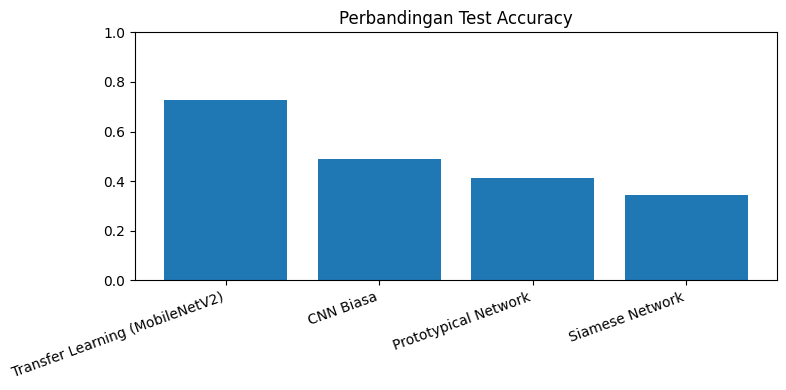

In [17]:
# [CRISP-DM: Evaluation - Compare Models Plot] [SAFE-RERUN]
# Perbaikan sel tabel + plot akurasi (SELF-CONTAINED, restart-safe)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Bangun results jika belum ada
if 'results' not in globals() or not isinstance(results, pd.DataFrame):
    _rows = [
        {'Model': 'CNN Biasa', 'Test Accuracy': float(globals()['acc_cnn']) if 'acc_cnn' in globals() and globals()['acc_cnn'] is not None else np.nan},
        {'Model': 'Transfer Learning (MobileNetV2)', 'Test Accuracy': float(globals()['acc_tl']) if 'acc_tl' in globals() and globals()['acc_tl'] is not None else np.nan},
        {'Model': 'Siamese Network', 'Test Accuracy': float(globals()['acc_siamese']) if 'acc_siamese' in globals() and globals()['acc_siamese'] is not None else np.nan},
        {'Model': 'Prototypical Network', 'Test Accuracy': float(globals()['acc_proto']) if 'acc_proto' in globals() and globals()['acc_proto'] is not None else np.nan},
    ]
    results = pd.DataFrame(_rows).sort_values('Test Accuracy', ascending=False, na_position='last').reset_index(drop=True)

print(results)
plt.figure(figsize=(8, 4))
plot_df = results.dropna(subset=['Test Accuracy'])
if len(plot_df) == 0:
    print('Belum ada nilai akurasi yang tersedia untuk diplot.')
else:
    plt.bar(plot_df['Model'], plot_df['Test Accuracy'])
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha='right')
    plt.title('Perbandingan Test Accuracy')
    plt.tight_layout()
    plt.show()


In [18]:
# [CRISP-DM: Deployment - All-in-One Prep (Transfer Final)] [SAFE-RERUN]
# POST-TRAIN ALL-IN-ONE (FORCE TRANSFER, restart-safe, anti-bolak-balik)
# Jalankan setelah tabel/grafik hasil.
import os
import json
import pathlib
import numpy as np
import tensorflow as tf

print('=== POST-TRAIN ALL-IN-ONE START ===')
DEPLOY_DIR = globals().get('DEPLOY_DIR', './artifacts')


def _find_artifacts_dir(prefer=None):
    candidates = []
    if prefer:
        candidates.append(prefer)
    candidates.extend([
        '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts',
        '/content/artifacts',
        './artifacts',
        'artifacts',
    ])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        if os.path.isdir(c):
            return c
    return prefer or './artifacts'


def _load_labels_meta(art_dir):
    labels_path = os.path.join(art_dir, 'class_names.npy')
    meta_path = os.path.join(art_dir, 'meta.json')
    labels = None
    meta = None
    if os.path.exists(labels_path):
        try:
            labels = np.load(labels_path, allow_pickle=True).tolist()
        except Exception:
            labels = None
    if os.path.exists(meta_path):
        try:
            with open(meta_path, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = None
    return labels, meta


def _load_transfer_from_disk(art_dir):
    for fname in ['transfer_model.keras', 'transfer.keras', 'best_model.keras', 'best_model.h5']:
        fpath = os.path.join(art_dir, fname)
        if not os.path.exists(fpath):
            continue
        try:
            model = tf.keras.models.load_model(fpath, compile=False)
            return model, fpath
        except Exception:
            continue
    return None, None


def _infer_img_size(model=None, fallback_meta=None):
    if isinstance(fallback_meta, dict) and 'img_size' in fallback_meta:
        try:
            h, w = fallback_meta['img_size']
            return [int(h), int(w)]
        except Exception:
            pass
    if model is not None:
        try:
            shp = model.input_shape
            if isinstance(shp, list):
                shp = shp[0]
            return [int(shp[1]), int(shp[2])]
        except Exception:
            pass
    if 'IMG_SIZE' in globals() and isinstance(IMG_SIZE, (list, tuple)) and len(IMG_SIZE) == 2:
        return [int(IMG_SIZE[0]), int(IMG_SIZE[1])]
    return [224, 224]


def _build_app_py():
    app_code = r'''import os
import json
import pathlib
import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

st.set_page_config(page_title='Durian Leaf Classifier', page_icon='leaf', layout='centered')

def find_artifacts_dir():
    candidates = []
    env_dir = os.environ.get('DUREN_ARTIFACTS_DIR')
    if env_dir:
        candidates.append(env_dir)
    candidates.extend(['/mount/src/artifacts', './artifacts', 'artifacts', '/content/artifacts', '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts'])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        export_dir = os.path.join(c, 'best_model_savedmodel')
        labels_path = os.path.join(c, 'class_names.npy')
        meta_path = os.path.join(c, 'meta.json')
        if os.path.exists(export_dir) and os.path.exists(labels_path) and os.path.exists(meta_path):
            return c
    return None

DEPLOY_DIR = find_artifacts_dir()
if DEPLOY_DIR is None:
    st.error('Artifacts deploy tidak ditemukan. Pastikan folder artifacts berisi best_model_savedmodel, class_names.npy, dan meta.json.')
    st.stop()

EXPORT_DIR = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
LABELS_PATH = os.path.join(DEPLOY_DIR, 'class_names.npy')
META_PATH = os.path.join(DEPLOY_DIR, 'meta.json')

@st.cache_resource
def load_assets():
    model_obj = tf.saved_model.load(EXPORT_DIR)
    infer = model_obj.signatures['serving_default']
    class_names = np.load(LABELS_PATH, allow_pickle=True).tolist()
    with open(META_PATH, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    return infer, class_names, meta

infer, class_names, meta = load_assets()
img_h, img_w = meta['img_size']
st.title('Durian Leaf Disease Classifier')
acc_val = meta.get('best_model_accuracy', None)
if isinstance(acc_val, (int, float)) and float(acc_val) >= 0:
    st.caption(f"Model final riset: {meta.get('best_model_name', 'transfer')} | Test Accuracy: {float(acc_val):.4f}")
else:
    st.caption(f"Model final riset: {meta.get('best_model_name', 'transfer')} | Test Accuracy: N/A")
uploaded = st.file_uploader('Upload leaf image', type=['jpg', 'jpeg', 'png'])
if uploaded is not None:
    img = Image.open(uploaded).convert('RGB')
    st.image(img, caption='Input Image', use_container_width=True)
    x = img.resize((img_w, img_h))
    x = np.array(x).astype('float32') / 255.0
    x = np.expand_dims(x, axis=0)
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    out_dict = infer(x_tf)
    probs = list(out_dict.values())[0].numpy()[0]
    pred_idx = int(np.argmax(probs))
    st.subheader(f"Prediction: {class_names[pred_idx]}")
    st.write(f"Confidence: {float(probs[pred_idx]):.4f}")
    chart_data = {'Class': class_names, 'Probability': [float(p) for p in probs]}
    st.bar_chart(data=chart_data, x='Class', y='Probability')
'''
    with open('app.py', 'w', encoding='utf-8') as f:
        f.write(app_code)
    print('app.py dibuat')


def _build_requirements():
    reqs = "\n".join(["streamlit", "tensorflow", "numpy", "pillow"]) + "\n"
    with open('requirements.txt', 'w', encoding='utf-8') as f:
        f.write(reqs)
    print('requirements.txt dibuat')


try:
    DEPLOY_DIR = _find_artifacts_dir(DEPLOY_DIR)
    os.makedirs(DEPLOY_DIR, exist_ok=True)
    labels_disk, meta_disk = _load_labels_meta(DEPLOY_DIR)

    final_model = globals().get('transfer_model', None)
    if final_model is None:
        final_model, model_path = _load_transfer_from_disk(DEPLOY_DIR)
        if final_model is not None:
            print('Auto-loaded Transfer Learning dari artifacts:', model_path)

    if final_model is None:
        print('Transfer Learning belum tersedia di memori dan file .keras tidak ditemukan.')
        print('Saya tetap lanjut buat app.py + requirements.txt jika SavedModel sudah ada.')
    else:
        if 'class_names' in globals() and isinstance(class_names, (list, tuple)) and len(class_names) > 0:
            final_classes = list(class_names)
        elif labels_disk is not None:
            final_classes = list(labels_disk)
            class_names = final_classes
        else:
            final_classes = None

        if final_classes is None:
            print('class_names tidak tersedia. Lewati refresh artifacts model; app.py tetap akan dibuat.')
        else:
            final_acc = None
            if 'acc_tl' in globals() and globals().get('acc_tl') is not None:
                final_acc = float(acc_tl)
            elif isinstance(meta_disk, dict) and meta_disk.get('best_model_accuracy') is not None:
                try:
                    final_acc = float(meta_disk['best_model_accuracy'])
                except Exception:
                    final_acc = None
            if final_acc is None:
                final_acc = -1.0

            keras_path = os.path.join(DEPLOY_DIR, 'best_model.keras')
            try:
                final_model.save(keras_path)
                print('Keras model tersimpan:', keras_path)
            except Exception as e:
                print('Peringatan simpan .keras:', e)

            export_dir = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
            if tf.io.gfile.exists(export_dir):
                tf.io.gfile.rmtree(export_dir)
            if hasattr(final_model, 'export'):
                final_model.export(export_dir)
            else:
                tf.saved_model.save(final_model, export_dir)

            labels_path = os.path.join(DEPLOY_DIR, 'class_names.npy')
            np.save(labels_path, np.array(final_classes, dtype=object))

            meta = {
                'best_model_name': 'transfer',
                'best_model_accuracy': float(final_acc),
                'img_size': _infer_img_size(final_model, fallback_meta=meta_disk),
                'num_classes': int(len(final_classes)),
                'model_format': 'saved_model',
                'export_dir': export_dir,
                'selection_policy': 'forced_transfer_for_research_consistency'
            }
            meta_path = os.path.join(DEPLOY_DIR, 'meta.json')
            with open(meta_path, 'w', encoding='utf-8') as f:
                json.dump(meta, f, indent=2)
            print('Artifacts final transfer di-refresh.')

    _build_app_py()
    _build_requirements()

    print('=== STATUS FILE ===')
    for p in ['app.py', 'requirements.txt', DEPLOY_DIR]:
        print(p, 'exists=', os.path.exists(p))
    if os.path.isdir(DEPLOY_DIR):
        try:
            print('artifacts:', sorted(os.listdir(DEPLOY_DIR)))
        except Exception as e:
            print('gagal list artifacts:', e)
    print('=== POST-TRAIN ALL-IN-ONE DONE ===')
except Exception as e:
    print('POST-TRAIN ALL-IN-ONE tidak bikin notebook crash, tapi ada masalah:')
    print(type(e).__name__ + ':', e)


=== POST-TRAIN ALL-IN-ONE START ===
Transfer Learning belum tersedia di memori dan file .keras tidak ditemukan.
Saya tetap lanjut buat app.py + requirements.txt jika SavedModel sudah ada.
app.py dibuat
requirements.txt dibuat
=== STATUS FILE ===
app.py exists= True
requirements.txt exists= True
/content/drive/MyDrive/Colab Notebooks/Duren/artifacts exists= True
artifacts: ['best_model.keras', 'best_model_savedmodel', 'class_names.npy', 'meta.json']
=== POST-TRAIN ALL-IN-ONE DONE ===


In [19]:
# [CRISP-DM: Deployment - Save Final Artifacts (Transfer)] [SAFE-RERUN]
# Simpan model final untuk deploy (FORCE TRANSFER, konsisten riset, GRACEFUL)
import os
import json
import pathlib
import numpy as np
import tensorflow as tf

DEPLOY_DIR = globals().get('DEPLOY_DIR', './artifacts')


def _find_artifacts_dir(prefer=None):
    candidates = []
    if prefer:
        candidates.append(prefer)
    candidates.extend([
        '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts',
        '/content/artifacts',
        './artifacts',
        'artifacts',
    ])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        if os.path.isdir(c):
            return c
    return prefer or './artifacts'


def _load_labels_meta(art_dir):
    labels_path = os.path.join(art_dir, 'class_names.npy')
    meta_path = os.path.join(art_dir, 'meta.json')
    labels = None
    meta = None
    if os.path.exists(labels_path):
        try:
            labels = np.load(labels_path, allow_pickle=True).tolist()
        except Exception:
            labels = None
    if os.path.exists(meta_path):
        try:
            with open(meta_path, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = None
    return labels, meta


def _load_transfer_from_disk(art_dir):
    for fname in ['transfer_model.keras', 'transfer.keras', 'best_model.keras', 'best_model.h5']:
        fpath = os.path.join(art_dir, fname)
        if not os.path.exists(fpath):
            continue
        try:
            model = tf.keras.models.load_model(fpath, compile=False)
            return model, fpath
        except Exception:
            continue
    return None, None


def _infer_img_size(model, fallback_meta=None):
    if isinstance(fallback_meta, dict) and 'img_size' in fallback_meta:
        try:
            h, w = fallback_meta['img_size']
            return [int(h), int(w)]
        except Exception:
            pass
    try:
        shp = model.input_shape
        if isinstance(shp, list):
            shp = shp[0]
        return [int(shp[1]), int(shp[2])]
    except Exception:
        pass
    if 'IMG_SIZE' in globals() and len(IMG_SIZE) == 2:
        return [int(IMG_SIZE[0]), int(IMG_SIZE[1])]
    return [224, 224]


try:
    DEPLOY_DIR = _find_artifacts_dir(DEPLOY_DIR)
    os.makedirs(DEPLOY_DIR, exist_ok=True)
    loaded_labels, loaded_meta = _load_labels_meta(DEPLOY_DIR)

    final_model = None
    if 'transfer_model' in globals():
        final_model = transfer_model
        print('Menggunakan transfer_model dari memori runtime.')
    else:
        final_model, model_path = _load_transfer_from_disk(DEPLOY_DIR)
        if final_model is not None:
            print('Auto-loaded Transfer Learning dari artifacts:', model_path)

    # Fallback paling aman: kalau SavedModel sudah ada, jangan gagal keras
    existing_export = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
    if final_model is None and tf.io.gfile.exists(existing_export):
        print('Keras model tidak ditemukan, tapi SavedModel deploy sudah ada -> pakai artifacts yang ada (skip re-export).')
        if loaded_meta:
            print('Meta tersedia:', loaded_meta)
        else:
            print('Peringatan: meta.json belum ada.')
    else:
        if final_model is None:
            print('Tidak ada transfer_model di memori / file .keras di artifacts.')
            print('Solusi: jalankan evaluasi TL lalu sel ini, atau pastikan artifacts/best_model.keras ada.')
        else:
            if 'class_names' in globals() and isinstance(class_names, (list, tuple)) and len(class_names) > 0:
                _class_names = list(class_names)
            elif loaded_labels is not None:
                _class_names = list(loaded_labels)
                class_names = _class_names
            else:
                _class_names = None

            if _class_names is None:
                print('class_names tidak tersedia. Simpan artifacts/class_names.npy terlebih dahulu.')
            else:
                if 'acc_tl' in globals() and globals().get('acc_tl') is not None:
                    final_acc = float(acc_tl)
                elif isinstance(loaded_meta, dict) and loaded_meta.get('best_model_accuracy') is not None:
                    final_acc = float(loaded_meta['best_model_accuracy'])
                else:
                    final_acc = -1.0

                keras_path = os.path.join(DEPLOY_DIR, 'best_model.keras')
                try:
                    final_model.save(keras_path)
                    print('Keras model tersimpan:', keras_path)
                except Exception as e:
                    print('Peringatan: gagal menyimpan best_model.keras ->', e)

                export_dir = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
                if tf.io.gfile.exists(export_dir):
                    tf.io.gfile.rmtree(export_dir)
                if hasattr(final_model, 'export'):
                    final_model.export(export_dir)
                else:
                    tf.saved_model.save(final_model, export_dir)

                labels_path = os.path.join(DEPLOY_DIR, 'class_names.npy')
                np.save(labels_path, np.array(_class_names, dtype=object))

                meta = {
                    'best_model_name': 'transfer',
                    'best_model_accuracy': float(final_acc),
                    'img_size': _infer_img_size(final_model, fallback_meta=loaded_meta),
                    'num_classes': int(len(_class_names)),
                    'model_format': 'saved_model',
                    'export_dir': export_dir,
                    'selection_policy': 'forced_transfer_for_research_consistency'
                }
                meta_path = os.path.join(DEPLOY_DIR, 'meta.json')
                with open(meta_path, 'w', encoding='utf-8') as f:
                    json.dump(meta, f, indent=2)

                print('SavedModel export :', export_dir)
                print('Labels saved      :', labels_path)
                print('Meta saved        :', meta_path)
                print('Final model       : transfer')
                print('Final acc (TL)    :', final_acc if final_acc >= 0 else 'N/A (jalankan evaluasi TL untuk angka resmi)')
except Exception as e:
    print('SEL SIMPAN MODEL (GRACEFUL) tidak crash notebook, tapi ada masalah:')
    print(type(e).__name__ + ':', e)


Keras model tidak ditemukan, tapi SavedModel deploy sudah ada -> pakai artifacts yang ada (skip re-export).
Meta tersedia: {'best_model_name': 'transfer', 'best_model_accuracy': 0.6296296296296297, 'img_size': [224, 224], 'num_classes': 5}


Fallback ke SavedModel infer dari artifacts: /content/drive/MyDrive/Colab Notebooks/Duren/artifacts/best_model_savedmodel


Saving duren loro3.jpg to duren loro3.jpg
File: duren loro3.jpg


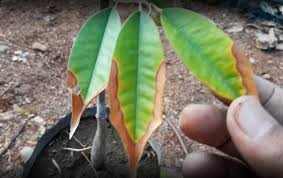

Model        : transfer
Predicted    : PHOMOPSIS_LEAF_SPOT
Confidence   : 0.5344


In [20]:
# [CRISP-DM: Deployment - Manual Predict (Transfer)] [SAFE-RERUN]
# Prediksi kelas dari gambar input (upload manual di Colab) - FORCE TRANSFER (riset final, GRACEFUL)
import os
import pathlib
import numpy as np
import tensorflow as tf
from PIL import Image

IN_COLAB = 'google.colab' in str(getattr(__import__('sys'), 'modules', {}))
if IN_COLAB:
    from IPython.display import display
    from google.colab import files
else:
    print('Bukan runtime Colab. Sel upload manual dilewati tanpa error.')

MODEL_TO_USE = 'transfer'


def _find_artifacts_dir():
    candidates = []
    if 'DEPLOY_DIR' in globals() and isinstance(DEPLOY_DIR, str):
        candidates.append(DEPLOY_DIR)
    candidates.extend(['./artifacts', 'artifacts', '/content/artifacts', '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts'])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        if os.path.isdir(c):
            return c
    return None


def _load_labels_and_meta(art_dir):
    labels = None
    meta = None
    if art_dir:
        lp = os.path.join(art_dir, 'class_names.npy')
        mp = os.path.join(art_dir, 'meta.json')
        if os.path.exists(lp):
            try:
                labels = np.load(lp, allow_pickle=True).tolist()
            except Exception:
                pass
        if os.path.exists(mp):
            try:
                import json
                with open(mp, 'r', encoding='utf-8') as f:
                    meta = json.load(f)
            except Exception:
                pass
    return labels, meta


def _load_transfer_keras(art_dir):
    if not art_dir:
        return None, None
    for fname in ['transfer_model.keras', 'transfer.keras', 'best_model.keras', 'best_model.h5']:
        fp = os.path.join(art_dir, fname)
        if os.path.exists(fp):
            try:
                return tf.keras.models.load_model(fp, compile=False), fp
            except Exception:
                continue
    return None, None


def _load_savedmodel_infer(art_dir):
    if not art_dir:
        return None, None
    export_dir = os.path.join(art_dir, 'best_model_savedmodel')
    if not os.path.exists(export_dir):
        return None, None
    try:
        obj = tf.saved_model.load(export_dir)
        infer = obj.signatures['serving_default']
        return infer, export_dir
    except Exception:
        return None, None


def _infer_img_size(model=None, meta=None):
    if isinstance(meta, dict) and 'img_size' in meta:
        try:
            h, w = meta['img_size']
            return (int(h), int(w))
        except Exception:
            pass
    if model is not None:
        try:
            shp = model.input_shape
            if isinstance(shp, list):
                shp = shp[0]
            return (int(shp[1]), int(shp[2]))
        except Exception:
            pass
    if 'IMG_SIZE' in globals() and isinstance(IMG_SIZE, (list, tuple)) and len(IMG_SIZE) == 2:
        return (int(IMG_SIZE[0]), int(IMG_SIZE[1]))
    return (224, 224)


if IN_COLAB:
    art_dir = _find_artifacts_dir()
    labels_art, meta_art = _load_labels_and_meta(art_dir)

    keras_model = globals().get('transfer_model', None)
    keras_path = None
    if keras_model is None:
        keras_model, keras_path = _load_transfer_keras(art_dir)
        if keras_model is not None:
            print('Auto-loaded Transfer Learning (Keras) dari artifacts:', keras_path)

    infer_fn = None
    savedmodel_path = None
    if keras_model is None:
        infer_fn, savedmodel_path = _load_savedmodel_infer(art_dir)
        if infer_fn is not None:
            print('Fallback ke SavedModel infer dari artifacts:', savedmodel_path)

    if labels_art is not None and ('class_names' not in globals() or not globals().get('class_names')):
        class_names = list(labels_art)

    if 'class_names' not in globals() or not class_names:
        print('Tidak bisa prediksi: class_names tidak tersedia (artifacts/class_names.npy tidak ditemukan).')
    elif keras_model is None and infer_fn is None:
        print('Tidak bisa prediksi: model transfer tidak tersedia di memori, file .keras, maupun SavedModel.')
        print('Pastikan folder artifacts berisi best_model.keras atau best_model_savedmodel.')
    else:
        uploaded = files.upload()
        if len(uploaded) == 0:
            print('Tidak ada file yang diupload.')
        else:
            img_name = list(uploaded.keys())[0]
            print('File:', img_name)
            img = tf.keras.utils.load_img(img_name, target_size=_infer_img_size(model=keras_model, meta=meta_art))
            img_arr = tf.keras.utils.img_to_array(img).astype('float32') / 255.0
            x = np.expand_dims(img_arr, axis=0)
            display(Image.open(img_name))

            if keras_model is not None:
                probs = keras_model.predict(x, verbose=0)[0]
            else:
                out = infer_fn(tf.convert_to_tensor(x, dtype=tf.float32))
                probs = list(out.values())[0].numpy()[0]

            pred_idx = int(np.argmax(probs))
            conf = float(probs[pred_idx])
            print('Model        : transfer')
            print('Predicted    :', class_names[pred_idx])
            print('Confidence   :', round(conf, 4))


In [ ]:
# [CRISP-DM: Deployment - Placeholder Compatibility] [SAFE-RERUN]
# Placeholder no-op (dipertahankan agar nomor sel lama tidak bergeser)
print('Cell placeholder: tidak ada aksi. Lanjut ke sel berikutnya.')


In [21]:
# [CRISP-DM: Deployment - Save Final Artifacts Alias] [SAFE-RERUN]
# Simpan model terbaik untuk deploy Streamlit - FORCE TRANSFER (konsisten riset, GRACEFUL)
# Alias kompatibilitas: menjalankan logika sel simpan model final.

# Simpan model final untuk deploy (FORCE TRANSFER, konsisten riset, GRACEFUL)
import os
import json
import pathlib
import numpy as np
import tensorflow as tf

DEPLOY_DIR = globals().get('DEPLOY_DIR', './artifacts')


def _find_artifacts_dir(prefer=None):
    candidates = []
    if prefer:
        candidates.append(prefer)
    candidates.extend([
        '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts',
        '/content/artifacts',
        './artifacts',
        'artifacts',
    ])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        if os.path.isdir(c):
            return c
    return prefer or './artifacts'


def _load_labels_meta(art_dir):
    labels_path = os.path.join(art_dir, 'class_names.npy')
    meta_path = os.path.join(art_dir, 'meta.json')
    labels = None
    meta = None
    if os.path.exists(labels_path):
        try:
            labels = np.load(labels_path, allow_pickle=True).tolist()
        except Exception:
            labels = None
    if os.path.exists(meta_path):
        try:
            with open(meta_path, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = None
    return labels, meta


def _load_transfer_from_disk(art_dir):
    for fname in ['transfer_model.keras', 'transfer.keras', 'best_model.keras', 'best_model.h5']:
        fpath = os.path.join(art_dir, fname)
        if not os.path.exists(fpath):
            continue
        try:
            model = tf.keras.models.load_model(fpath, compile=False)
            return model, fpath
        except Exception:
            continue
    return None, None


def _infer_img_size(model, fallback_meta=None):
    if isinstance(fallback_meta, dict) and 'img_size' in fallback_meta:
        try:
            h, w = fallback_meta['img_size']
            return [int(h), int(w)]
        except Exception:
            pass
    try:
        shp = model.input_shape
        if isinstance(shp, list):
            shp = shp[0]
        return [int(shp[1]), int(shp[2])]
    except Exception:
        pass
    if 'IMG_SIZE' in globals() and len(IMG_SIZE) == 2:
        return [int(IMG_SIZE[0]), int(IMG_SIZE[1])]
    return [224, 224]


try:
    DEPLOY_DIR = _find_artifacts_dir(DEPLOY_DIR)
    os.makedirs(DEPLOY_DIR, exist_ok=True)
    loaded_labels, loaded_meta = _load_labels_meta(DEPLOY_DIR)

    final_model = None
    if 'transfer_model' in globals():
        final_model = transfer_model
        print('Menggunakan transfer_model dari memori runtime.')
    else:
        final_model, model_path = _load_transfer_from_disk(DEPLOY_DIR)
        if final_model is not None:
            print('Auto-loaded Transfer Learning dari artifacts:', model_path)

    # Fallback paling aman: kalau SavedModel sudah ada, jangan gagal keras
    existing_export = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
    if final_model is None and tf.io.gfile.exists(existing_export):
        print('Keras model tidak ditemukan, tapi SavedModel deploy sudah ada -> pakai artifacts yang ada (skip re-export).')
        if loaded_meta:
            print('Meta tersedia:', loaded_meta)
        else:
            print('Peringatan: meta.json belum ada.')
    else:
        if final_model is None:
            print('Tidak ada transfer_model di memori / file .keras di artifacts.')
            print('Solusi: jalankan evaluasi TL lalu sel ini, atau pastikan artifacts/best_model.keras ada.')
        else:
            if 'class_names' in globals() and isinstance(class_names, (list, tuple)) and len(class_names) > 0:
                _class_names = list(class_names)
            elif loaded_labels is not None:
                _class_names = list(loaded_labels)
                class_names = _class_names
            else:
                _class_names = None

            if _class_names is None:
                print('class_names tidak tersedia. Simpan artifacts/class_names.npy terlebih dahulu.')
            else:
                if 'acc_tl' in globals() and globals().get('acc_tl') is not None:
                    final_acc = float(acc_tl)
                elif isinstance(loaded_meta, dict) and loaded_meta.get('best_model_accuracy') is not None:
                    final_acc = float(loaded_meta['best_model_accuracy'])
                else:
                    final_acc = -1.0

                keras_path = os.path.join(DEPLOY_DIR, 'best_model.keras')
                try:
                    final_model.save(keras_path)
                    print('Keras model tersimpan:', keras_path)
                except Exception as e:
                    print('Peringatan: gagal menyimpan best_model.keras ->', e)

                export_dir = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
                if tf.io.gfile.exists(export_dir):
                    tf.io.gfile.rmtree(export_dir)
                if hasattr(final_model, 'export'):
                    final_model.export(export_dir)
                else:
                    tf.saved_model.save(final_model, export_dir)

                labels_path = os.path.join(DEPLOY_DIR, 'class_names.npy')
                np.save(labels_path, np.array(_class_names, dtype=object))

                meta = {
                    'best_model_name': 'transfer',
                    'best_model_accuracy': float(final_acc),
                    'img_size': _infer_img_size(final_model, fallback_meta=loaded_meta),
                    'num_classes': int(len(_class_names)),
                    'model_format': 'saved_model',
                    'export_dir': export_dir,
                    'selection_policy': 'forced_transfer_for_research_consistency'
                }
                meta_path = os.path.join(DEPLOY_DIR, 'meta.json')
                with open(meta_path, 'w', encoding='utf-8') as f:
                    json.dump(meta, f, indent=2)

                print('SavedModel export :', export_dir)
                print('Labels saved      :', labels_path)
                print('Meta saved        :', meta_path)
                print('Final model       : transfer')
                print('Final acc (TL)    :', final_acc if final_acc >= 0 else 'N/A (jalankan evaluasi TL untuk angka resmi)')
except Exception as e:
    print('SEL SIMPAN MODEL (GRACEFUL) tidak crash notebook, tapi ada masalah:')
    print(type(e).__name__ + ':', e)


Keras model tidak ditemukan, tapi SavedModel deploy sudah ada -> pakai artifacts yang ada (skip re-export).
Meta tersedia: {'best_model_name': 'transfer', 'best_model_accuracy': 0.6296296296296297, 'img_size': [224, 224], 'num_classes': 5}


In [22]:
# [CRISP-DM: Deployment - Generate Streamlit App] [SAFE-RERUN]
# Buat app.py Streamlit - SELF-CONTAINED (restart-safe)
app_code = r'''
import os
import json
import pathlib
import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

st.set_page_config(page_title='Durian Leaf Classifier', page_icon='leaf', layout='centered')


def find_artifacts_dir():
    candidates = []
    env_dir = os.environ.get('DUREN_ARTIFACTS_DIR')
    if env_dir:
        candidates.append(env_dir)
    candidates.extend([
        '/mount/src/artifacts',
        './artifacts',
        'artifacts',
        '/content/artifacts',
        '/content/drive/MyDrive/Colab Notebooks/Duren/artifacts',
    ])
    try:
        cwd = pathlib.Path('.').resolve()
        for p in [cwd] + list(cwd.iterdir()):
            if p.is_dir() and p.name.lower() == 'artifacts':
                candidates.append(str(p))
    except Exception:
        pass
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        export_dir = os.path.join(c, 'best_model_savedmodel')
        labels_path = os.path.join(c, 'class_names.npy')
        meta_path = os.path.join(c, 'meta.json')
        if os.path.exists(export_dir) and os.path.exists(labels_path) and os.path.exists(meta_path):
            return c
    return None


DEPLOY_DIR = find_artifacts_dir()
if DEPLOY_DIR is None:
    st.error('Artifacts deploy tidak ditemukan. Pastikan folder artifacts berisi best_model_savedmodel, class_names.npy, dan meta.json.')
    st.stop()

EXPORT_DIR = os.path.join(DEPLOY_DIR, 'best_model_savedmodel')
LABELS_PATH = os.path.join(DEPLOY_DIR, 'class_names.npy')
META_PATH = os.path.join(DEPLOY_DIR, 'meta.json')


@st.cache_resource
def load_assets():
    model_obj = tf.saved_model.load(EXPORT_DIR)
    infer = model_obj.signatures['serving_default']
    class_names = np.load(LABELS_PATH, allow_pickle=True).tolist()
    with open(META_PATH, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    return infer, class_names, meta


infer, class_names, meta = load_assets()
img_h, img_w = meta['img_size']

st.title('Durian Leaf Disease Classifier')
acc_val = meta.get('best_model_accuracy', None)
if isinstance(acc_val, (int, float)) and float(acc_val) >= 0:
    st.caption(f"Model final riset: {meta.get('best_model_name', 'transfer')} | Test Accuracy: {float(acc_val):.4f}")
else:
    st.caption(f"Model final riset: {meta.get('best_model_name', 'transfer')} | Test Accuracy: N/A")

uploaded = st.file_uploader('Upload leaf image', type=['jpg', 'jpeg', 'png'])
if uploaded is not None:
    img = Image.open(uploaded).convert('RGB')
    st.image(img, caption='Input Image', use_container_width=True)
    x = img.resize((img_w, img_h))
    x = np.array(x).astype('float32') / 255.0
    x = np.expand_dims(x, axis=0)
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)

    out_dict = infer(x_tf)
    probs = list(out_dict.values())[0].numpy()[0]
    pred_idx = int(np.argmax(probs))

    st.subheader(f"Prediction: {class_names[pred_idx]}")
    st.write(f"Confidence: {float(probs[pred_idx]):.4f}")
    chart_data = {'Class': class_names, 'Probability': [float(p) for p in probs]}
    st.bar_chart(data=chart_data, x='Class', y='Probability')
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print('app.py dibuat (self-contained, baca artifacts)')


app.py dibuat (self-contained, baca artifacts)


In [ ]:
# [CRISP-DM: Deployment - Install Streamlit/Cloudflared] [RUN-ONCE-IF-NEEDED]
!pip install -q streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 40.5 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.2.0) ...
Setting up cloudflared (2026.2.0) ...
Processing triggers for man-db (2.10.2-1) ...


In [23]:
# [CRISP-DM: Deployment - Run Streamlit Tunnel] [SAFE-RERUN]
# Jalankan Streamlit via Cloudflare Tunnel (tanpa password interstitial) - GRACEFUL
import os
import subprocess
import time
import re

if not os.path.exists('app.py'):
    print('app.py belum ada. Jalankan sel "Buat app.py Streamlit" dulu.')
else:
    try:
        proc_streamlit = subprocess.Popen([
            'streamlit', 'run', 'app.py',
            '--server.port', '8501',
            '--server.address', '0.0.0.0',
            '--server.headless', 'true'
        ], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        print('PID streamlit:', proc_streamlit.pid)
        time.sleep(4)

        proc_cf = subprocess.Popen([
            'cloudflared', 'tunnel', '--url', 'http://localhost:8501', '--no-autoupdate'
        ], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

        print('Menunggu URL Cloudflare...')
        cf_url = None
        for _ in range(120):
            line = proc_cf.stdout.readline().strip()
            if line:
                print(line)
                m = re.search(r'https://[-a-zA-Z0-9]+\.trycloudflare\.com', line)
                if m:
                    cf_url = m.group(0)
                    break

        if cf_url:
            print('Streamlit URL (Cloudflare):', cf_url)
        else:
            print('URL Cloudflare belum terbaca. Cek output cloudflared di atas.')
    except FileNotFoundError as e:
        print('Dependency belum terpasang:', e)
        print('Jalankan sel install streamlit/cloudflared dulu (sel 26).')
    except Exception as e:
        print('Sel tunnel tidak crash notebook, tapi ada masalah:')
        print(type(e).__name__ + ':', e)


Dependency belum terpasang: [Errno 2] No such file or directory: 'streamlit'
Jalankan sel install streamlit/cloudflared dulu (sel 26).
